In [ ]:
# Install transformers from the PR branch until it's merged!
!pip install git+https://github.com/baptiste-aubertin/transformers.git@83d01ff90112ea3a0d8a6679aa9383e80f31c1db

  Cloning https://github.com/baptiste-aubertin/transformers.git (to revision 83d01ff90112ea3a0d8a6679aa9383e80f31c1db) to /tmp/pip-req-build-n6j8h0kh
  Running command git clone --filter=blob:none --quiet https://github.com/baptiste-aubertin/transformers.git /tmp/pip-req-build-n6j8h0kh
  Running command git rev-parse -q --verify 'sha^83d01ff90112ea3a0d8a6679aa9383e80f31c1db'
  Running command git fetch -q https://github.com/baptiste-aubertin/transformers.git 83d01ff90112ea3a0d8a6679aa9383e80f31c1db
  Running command git checkout -q 83d01ff90112ea3a0d8a6679aa9383e80f31c1db
  Resolved https://github.com/baptiste-aubertin/transformers.git to commit 83d01ff90112ea3a0d8a6679aa9383e80f31c1db
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, LightOnOCRForConditionalGeneration
from io import BytesIO

# Load Model
model_id = "lightonai/LightOnOCR-1B-1025"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_id)
model = LightOnOCRForConditionalGeneration.from_pretrained(model_id, dtype=torch.bfloat16, device_map=device, attn_implementation="sdpa")
model.eval();

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/720 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/703 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

You are using a model of type mistral3 to instantiate a model of type lightonocr. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/533 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

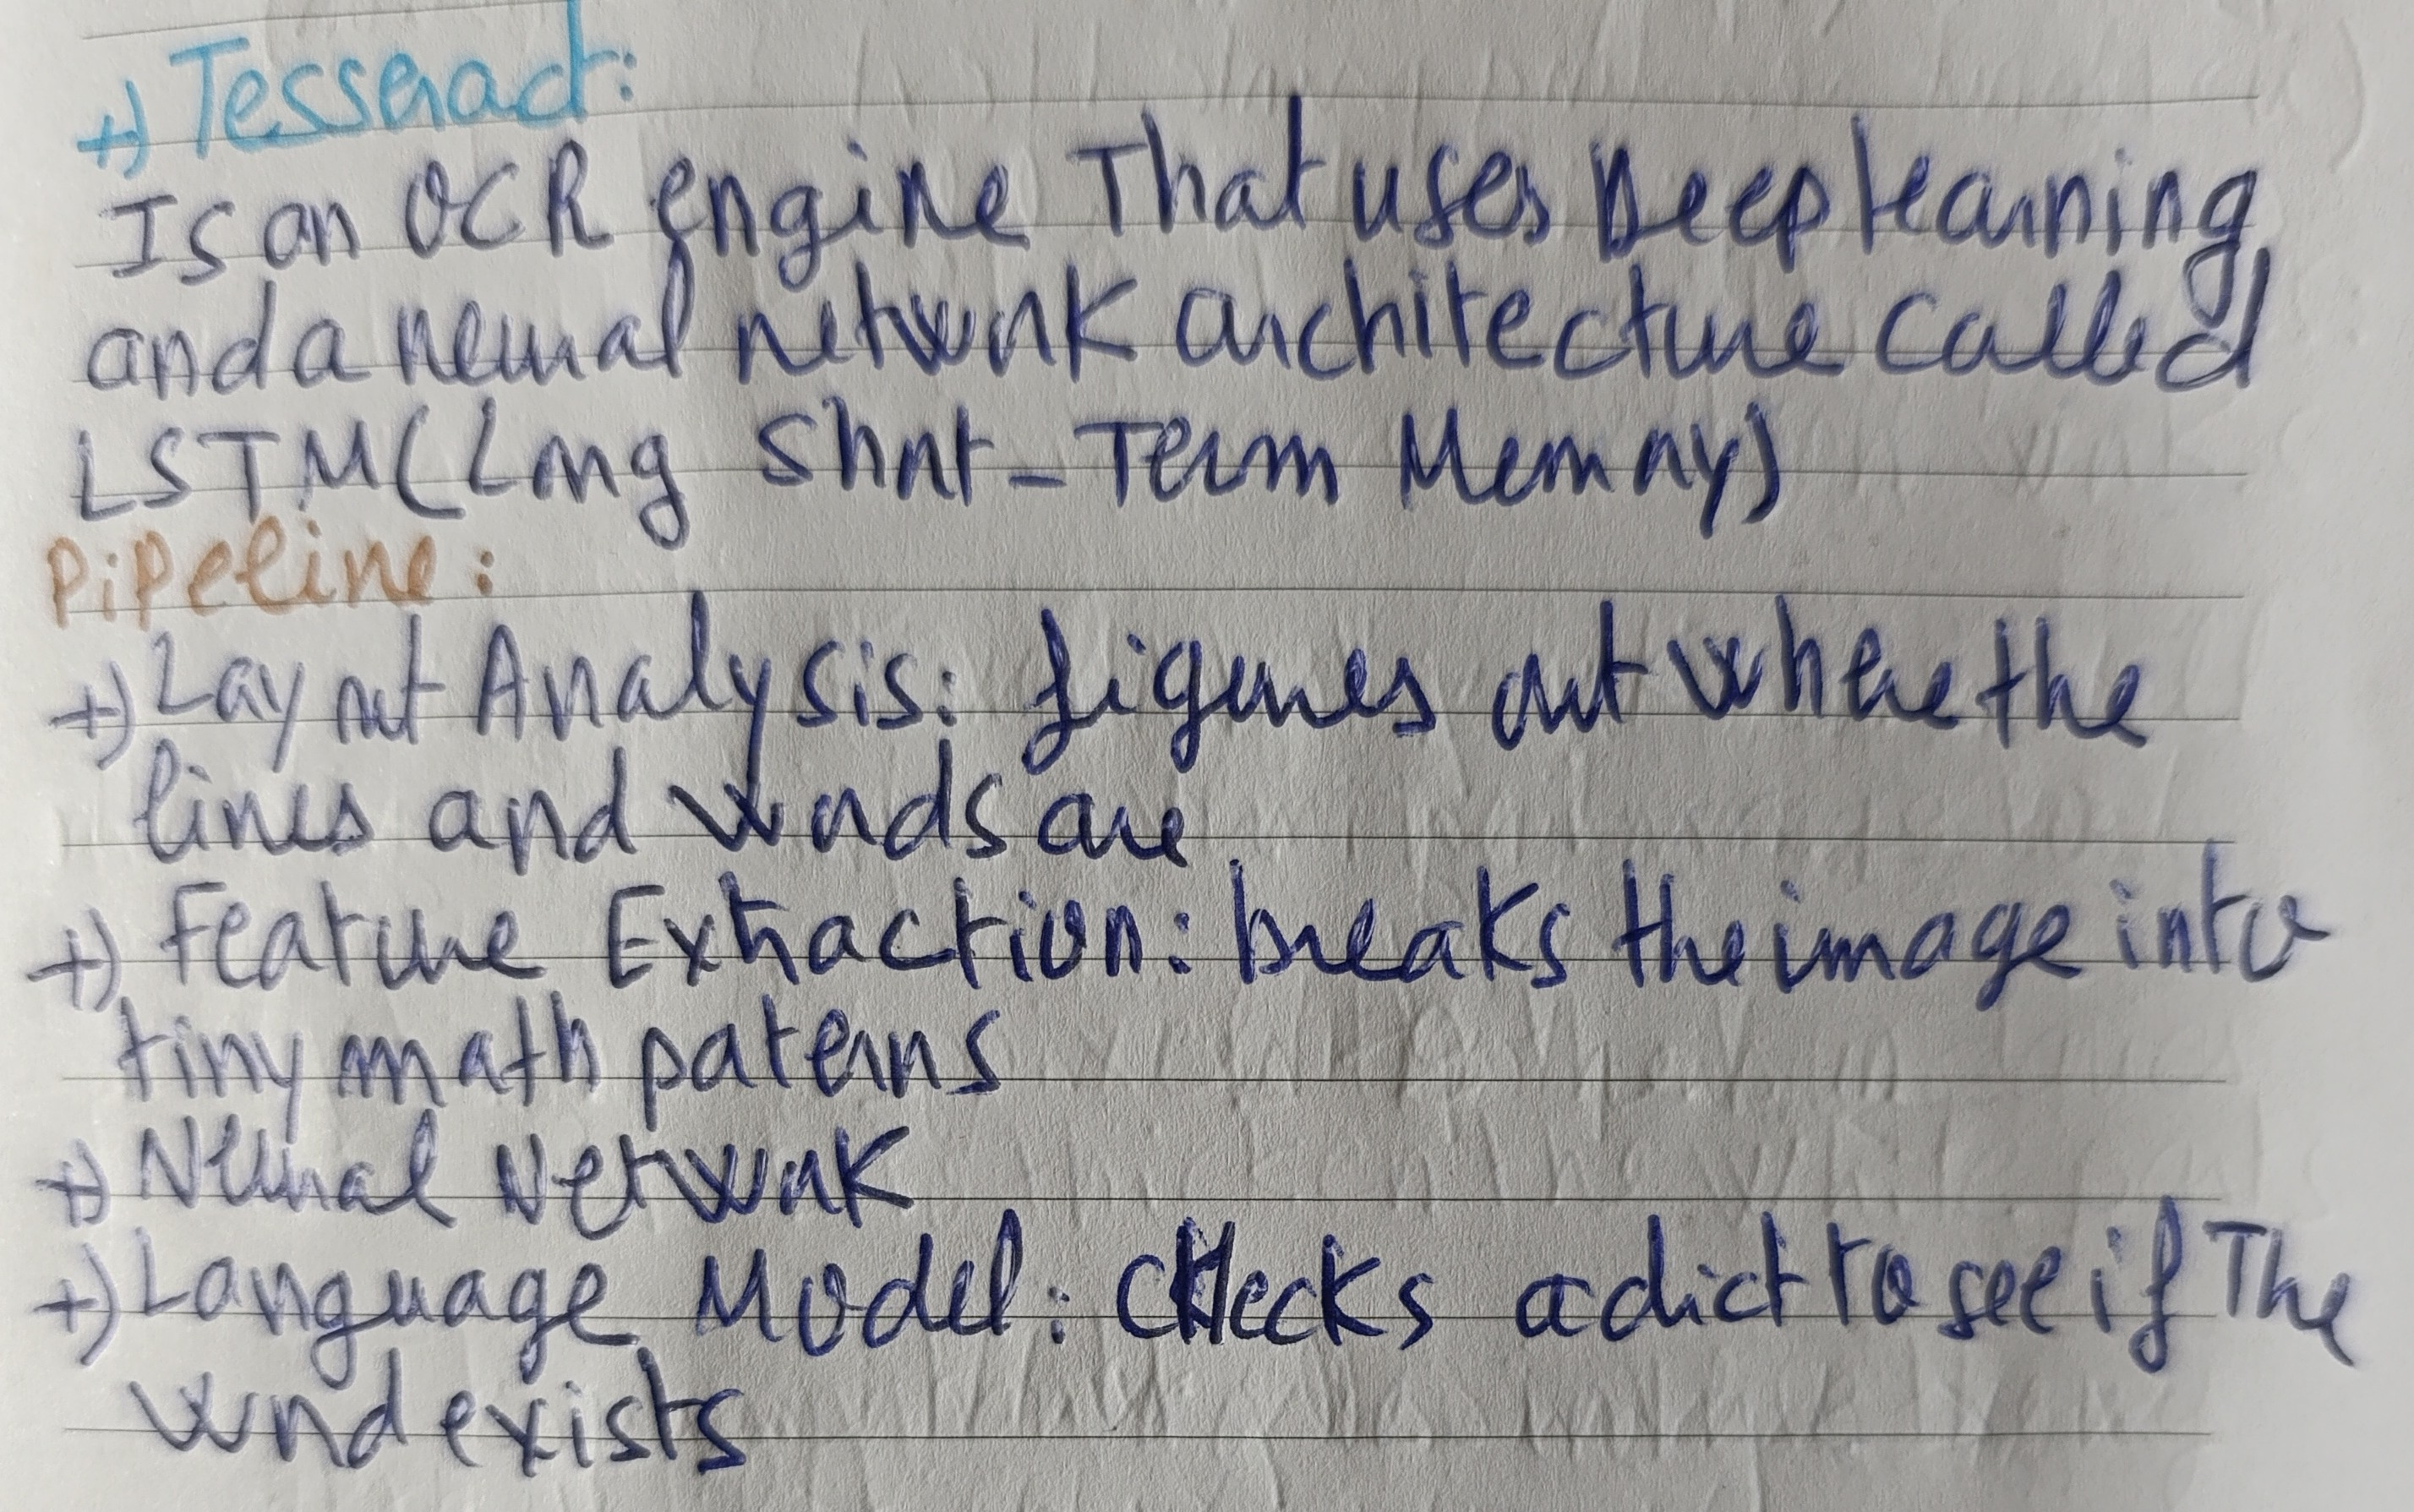


# Tesseract

- **Is an OCR engine that uses deep learning and a neural network architecture called LSTM (Long Short-Term Memory).**
- **Pipeline:**
  - **Image Analysis:** Figures and whee the lines and wads are
  - **Feature Extraction:** breaks the image into tiny math patterns
  - **Neural Network**
  - **Language Model:** checks a dict to see if they exist


In [ ]:
image = Image.open("/media/test6.jpg").convert("RGB")

display(image)

# Run inference
messages = [{"role": "user", "content": [{"type": "image"}]}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

inputs = processor(text=[text], images=[image], return_tensors="pt").to(device)
inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

outputs = model.generate(
    **inputs,
    max_new_tokens=248,
)

input_length = inputs['input_ids'].shape[1]
generated_text = processor.tokenizer.decode(outputs[0, input_length:], skip_special_tokens=True)

print("============\n")
print(generated_text)